In [ ]:
!pip install opencv-python scikit-image scikit-learn matplotlib

LBP Histogram (Smooth Image):
[0.01037215 0.01948915 0.00711263 0.02398096 0.01764441 0.10379704
 0.02018867 0.03598837 0.72726444 0.03416219]

LBP Histogram (Textured Image):
[0.02556721 0.05167831 0.02217796 0.1150108  0.22140623 0.19477344
 0.0653636  0.07216676 0.14351693 0.08833876]


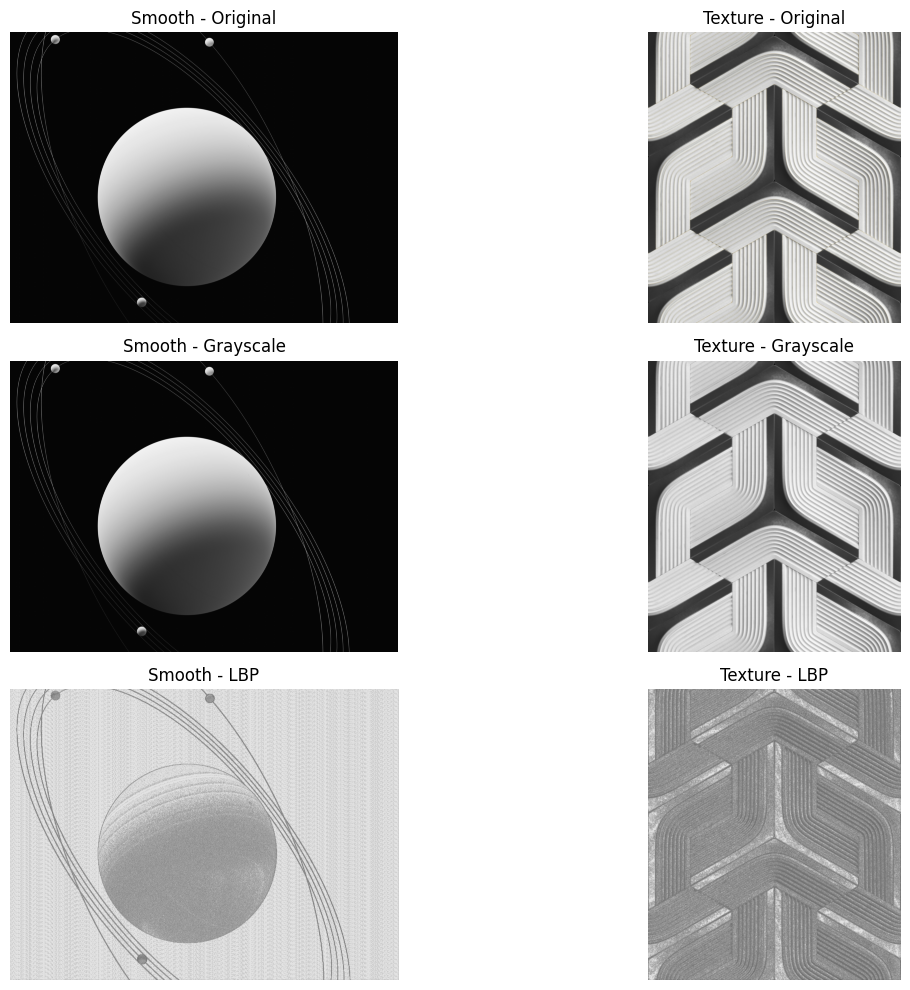

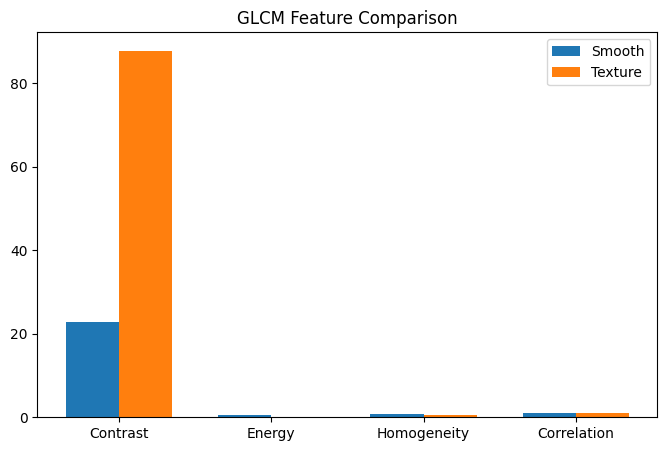

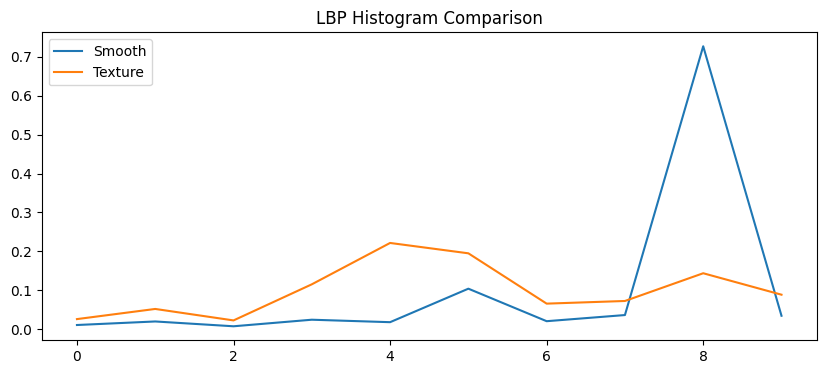

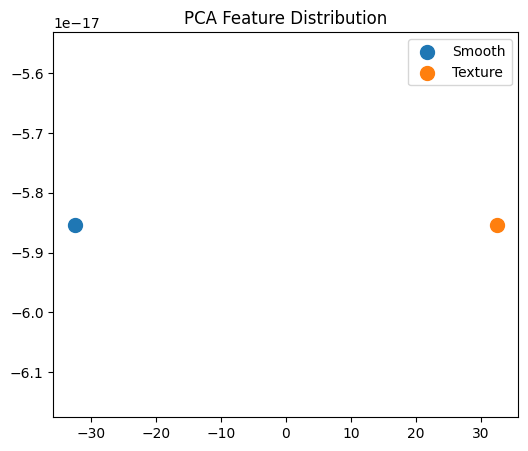

GLCM Features:
Smooth: [np.float64(22.864101498397886), np.float64(0.6268096813967485), np.float64(0.8580593847949683), np.float64(0.997129934208428)]
Texture: [np.float64(87.83788528534643), np.float64(0.0352173418194262), np.float64(0.43273681537657366), np.float64(0.99018457253688)]

PCA Result:
Smooth: [-3.24904991e+01 -5.85356727e-17]
Texture: [ 3.24904991e+01 -5.85356727e-17]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.decomposition import PCA

# Load images
img1 = cv2.imread('/content/Task5(1).jpg')
img2 = cv2.imread('/content/Task5(2).jpg')

# Safety check
if img1 is None or img2 is None:
    raise Exception("Image not loaded. Check file path.")

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# GLCM FEATURES
def get_glcm_features(image):
    glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]

    return [contrast, energy, homogeneity, correlation]

glcm1 = get_glcm_features(gray1)
glcm2 = get_glcm_features(gray2)

# ---------------------------
# 🔹 LBP FEATURES + VISUALIZATION
# ---------------------------

from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import numpy as np

def get_lbp(image):
    radius = 1
    n_points = 8 * radius

    # Compute LBP
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')

    # Histogram (feature vector)
    hist, bins = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2),
        density=True
    )

    return lbp, hist

# Apply LBP
lbp_img1, lbp1 = get_lbp(gray1)
lbp_img2, lbp2 = get_lbp(gray2)

# ---------------------------
# 🔹 PRINT FEATURE VALUES
# ---------------------------
print("LBP Histogram (Smooth Image):")
print(lbp1)

print("\nLBP Histogram (Textured Image):")
print(lbp2)

# PCA
features = np.array([glcm1 + list(lbp1), glcm2 + list(lbp2)])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# DISPLAY EVERYTHING SIDE BY SIDE
plt.figure(figsize=(14,10))

# Original Images
plt.subplot(3,2,1)
plt.title("Smooth - Original")
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,2,2)
plt.title("Texture - Original")
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Grayscale Images
plt.subplot(3,2,3)
plt.title("Smooth - Grayscale")
plt.imshow(gray1, cmap='gray')
plt.axis('off')

plt.subplot(3,2,4)
plt.title("Texture - Grayscale")
plt.imshow(gray2, cmap='gray')
plt.axis('off')

# LBP Images
plt.subplot(3,2,5)
plt.title("Smooth - LBP")
plt.imshow(lbp_img1, cmap='gray')
plt.axis('off')

plt.subplot(3,2,6)
plt.title("Texture - LBP")
plt.imshow(lbp_img2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# GLCM BAR COMPARISON
labels = ['Contrast', 'Energy', 'Homogeneity', 'Correlation']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, glcm1, width, label='Smooth')
plt.bar(x + width/2, glcm2, width, label='Texture')

plt.xticks(x, labels)
plt.title("GLCM Feature Comparison")
plt.legend()
plt.show()

# LBP HISTOGRAM COMPARISON
plt.figure(figsize=(10,4))
plt.plot(lbp1, label="Smooth")
plt.plot(lbp2, label="Texture")
plt.title("LBP Histogram Comparison")
plt.legend()
plt.show()

# PCA VISUALIZATION
plt.figure(figsize=(6,5))

plt.scatter(pca_result[0,0], pca_result[0,1], label="Smooth", s=100)
plt.scatter(pca_result[1,0], pca_result[1,1], label="Texture", s=100)

plt.title("PCA Feature Distribution")
plt.legend()
plt.show()

# PRINT VALUES
print("GLCM Features:")
print("Smooth:", glcm1)
print("Texture:", glcm2)

print("\nPCA Result:")
print("Smooth:", pca_result[0])
print("Texture:", pca_result[1])